In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


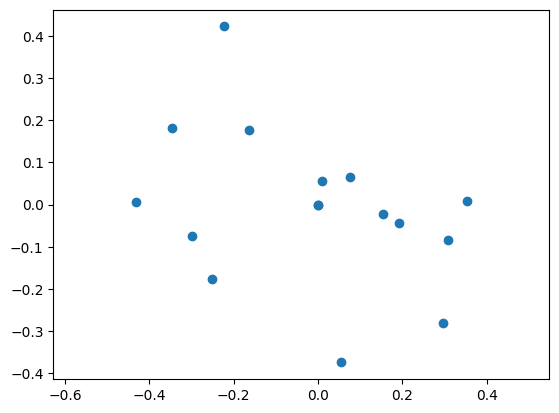

In [2]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=16,  # 轨迹的控制点数量 16
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.3
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.3

plt.scatter(xs, ys)
plt.axis('equal')
pass

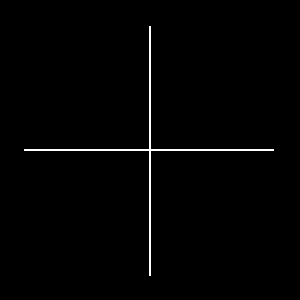

In [4]:
# 可视化墙（白色区域为墙）

import math
from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    i1 = int(ti.math.atan2(y1, x1) / (ti.math.pi * 2) * 4 % 4)
    i2 = int(ti.math.atan2(y2, x2) / (ti.math.pi * 2) * 4 % 4)
    return i1 != i2 and ti.Vector([x2, y2]).norm() < 1

image = test_forbidden_function(
    is_forbidden,
    -1.2, 1.2, -1.2, 1.2, [300, 300],
    wall_normal=[0.02, 0.02]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
# xs, ys, rotations = np.load('../trajectory/能让正五边形旋转一周的房间_0/sofa_600.npy')

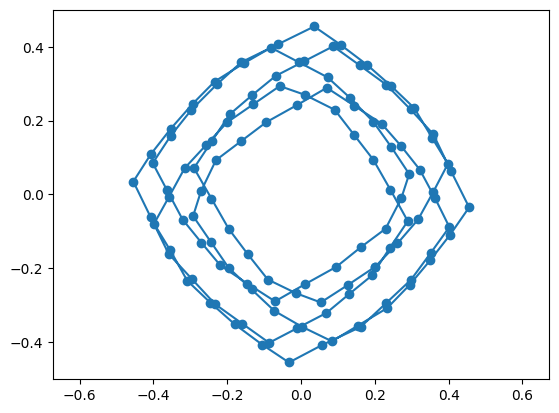

In [18]:
plt.plot(xs, ys, 'o-')
plt.axis('equal')
plt.show()

initial area = 10.179941177368164, initial loss = -10.179941177368164
iter 500 / 20000, maximal_area = 10.18010425567627, loss = -10.18010425567627
iter 1000 / 20000, maximal_area = 10.180501937866211, loss = -10.180501937866211
iter 1500 / 20000, maximal_area = 10.180548667907715, loss = -10.180548667907715
iter 2000 / 20000, maximal_area = 10.18100357055664, loss = -10.18100357055664
iter 2500 / 20000, maximal_area = 10.181144714355469, loss = -10.181144714355469
iter 3000 / 20000, maximal_area = 10.181436538696289, loss = -10.181436538696289
iter 3500 / 20000, maximal_area = 10.181716918945312, loss = -10.181716918945312
iter 4000 / 20000, maximal_area = 10.181751251220703, loss = -10.181751251220703
iter 4500 / 20000, maximal_area = 10.181844711303711, loss = -10.181844711303711
iter 5000 / 20000, maximal_area = 10.182090759277344, loss = -10.182090759277344
iter 5500 / 20000, maximal_area = 10.182207107543945, loss = -10.182207107543945
iter 6000 / 20000, maximal_area = 10.1825695

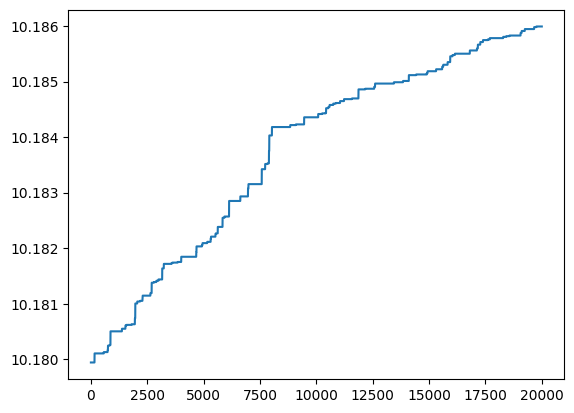

In [ ]:
sofa_w, sofa_h = 3.5, 3.5   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    ys,
    rotations,
    # initial_xs=zoom(xs, zoom=(2 * len(xs) - 1) / len(xs), order=1),  # 保持轨迹分辨率时注释掉这三行
    # initial_ys=zoom(ys, zoom=(2 * len(ys) - 1) / len(ys), order=1),
    # initial_rotations=zoom(rotations, zoom=(2 * len(rotations) - 1) / len(rotations), order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    iterations = 10000,  # 10000
    auto_divide_trajectory=True,
    mutation_sigma_pos = 0.02,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率
    auto_adjust_mutation_rate=True,
    trajectory_upsampling=21,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让四分支旋转一周的房间_1/sofa_',
    save_image_start_id=0,  # 文件起始标号
    save_trajectory_path='../trajectory/能让四分支旋转一周的房间_1/sofa_',
    boundary_conditions='periodic'  # 循环边界条件
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [10]:
len(xs)

31

In [19]:
from utils import get_area

best_score = get_area(is_forbidden, xs, ys, rotations, sofa_w, sofa_h, resolution=5000, trajectory_upsampling=200)  # 以很高的分辨率计算面积

area = sofa_w * sofa_h - best_score  # 房间面积
area_disk = np.pi  # 圆的面积
area / area_disk
print(f'相对于外接圆：{area} / {area_disk} = {area / area_disk}')

相对于外接圆：2.064291000366211 / 3.141592653589793 = 0.657084233376792


In [54]:
# 让电脑休眠

import os

os.system("rundll32.exe powrprof.dll,SetSuspendState 0,1,0")

0